# Model 2: Leakage-Safe LSTM Forecast

**Objective:** predict Botswana food-price inflation (`FAO_23014`) one month ahead using only information available before the forecast month.

The notebook uses chronological splits, training-only scaling, persistence and seasonal-naive baselines, a compact PyTorch LSTM, and out-of-sample diagnostics. Model selection uses validation RMSE; the test set remains untouched until the final configuration is selected.

In [3]:
%pip install numpy pandas matplotlib torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
    --------------------------------------- 0.3/12.4 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.4 MB 3.3 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/12.4 MB 4.6 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.4 MB 5.0 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.4 MB 5.4 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.4 MB 5.1 MB/s eta 0:00:02
   --------------------- ------------------ 6.8/12.4 MB 4.9 MB/s eta 0:00:02
   --------------------------- ------------ 8.4/12.4 MB 5.2 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.4 MB 5.3 MB/s eta 0:00:01
   ---------------------------------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
from pathlib import Path
import copy
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| device:', DEVICE)

PyTorch: 2.13.0+cpu | device: cpu


## 1. Load and validate the monthly data

The path is relative to the repository, so the notebook is portable across team members' computers.

In [5]:
DATA_PATH = Path('Data_Clean') / 'prediction_data.csv'
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['year_month'], format='%Y-%m')
df = df.sort_values('date').reset_index(drop=True)

expected_dates = pd.date_range(df['date'].min(), df['date'].max(), freq='MS')
quality = pd.Series({
    'rows': len(df),
    'start': df['date'].min().date(),
    'end': df['date'].max().date(),
    'missing_values': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'duplicate_months': int(df['date'].duplicated().sum()),
    'missing_months': int(len(expected_dates.difference(df['date']))),
    'chronologically_sorted': bool(df['date'].is_monotonic_increasing),
})
display(quality.to_frame('value'))
display(df.head())

,value
rows,276
start,2001-01-01
end,2023-12-01
missing_values,0
duplicate_rows,0
duplicate_months,0
missing_months,0
chronologically_sorted,True


,year_month,FAO_23012,FAO_23013,FAO_23014,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,date
0,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,2001-01-01
1,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,2001-02-01
2,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,2001-03-01
3,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,2001-04-01
4,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,2001-05-01


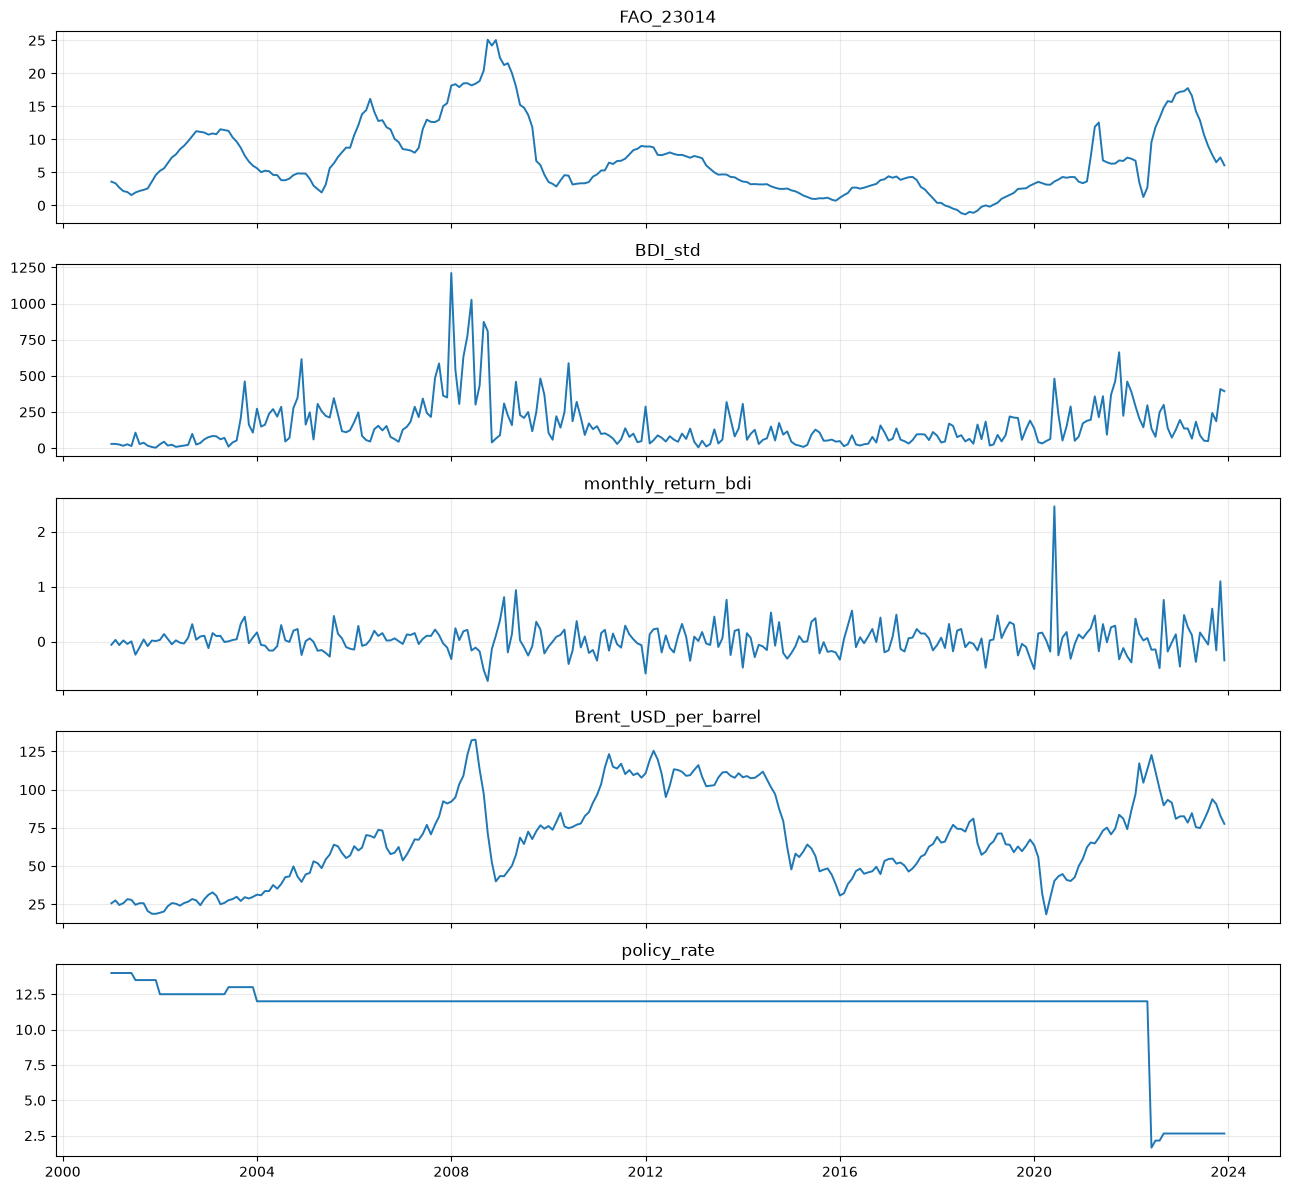

,missing,IQR_flag_count
FAO_23012,0,0
FAO_23013,0,0
FAO_23014,0,13
BDI_std,0,18
first,0,20
last,0,19
monthly_return_bdi,0,11
Brent_USD_per_barrel,0,0
policy_rate,0,55


IQR flags are investigation prompts, not automatic deletion rules. Economic shocks are retained.


In [6]:
TARGET = 'FAO_23014'
PLOT_COLUMNS = [TARGET, 'BDI_std', 'monthly_return_bdi', 'Brent_USD_per_barrel', 'policy_rate']

fig, axes = plt.subplots(len(PLOT_COLUMNS), 1, figsize=(13, 12), sharex=True)
for ax, column in zip(axes, PLOT_COLUMNS):
    ax.plot(df['date'], df[column], linewidth=1.4)
    ax.set_title(column)
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

numeric = df.select_dtypes(include=np.number)
q1, q3 = numeric.quantile(0.25), numeric.quantile(0.75)
iqr = q3 - q1
outlier_counts = ((numeric < q1 - 1.5 * iqr) | (numeric > q3 + 1.5 * iqr)).sum()
display(pd.DataFrame({'missing': numeric.isna().sum(), 'IQR_flag_count': outlier_counts}))
print('IQR flags are investigation prompts, not automatic deletion rules. Economic shocks are retained.')

## 2. Forecast definition and leakage controls

For a target dated month $t+1$, every input row is dated no later than month $t$. The current forecast month's price index and market measurements are therefore never used.

`FAO_23014` is almost exactly the 12-month percentage change of `FAO_23013`. This notebook may use historical `FAO_23013`, but never its value from the month being predicted.

In [7]:
reconstructed = df['FAO_23013'].pct_change(12) * 100
comparison = pd.DataFrame({'reported': df[TARGET], 'reconstructed': reconstructed}).dropna()
print('Maximum reconstruction error:', (comparison['reported'] - comparison['reconstructed']).abs().max())

# Historical target and historical predictors available by the end of each input month.
# `first` and `last` are excluded because they duplicate much of the BDI level information.
FEATURES = [
    TARGET,
    'FAO_23012',
    'FAO_23013',
    'BDI_std',
    'monthly_return_bdi',
    'Brent_USD_per_barrel',
    'policy_rate',
]

df['month_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)
FEATURES += ['month_sin', 'month_cos']
print('Features:', FEATURES)

Maximum reconstruction error: 2.7755360214598568e-06
Features: ['FAO_23014', 'FAO_23012', 'FAO_23013', 'BDI_std', 'monthly_return_bdi', 'Brent_USD_per_barrel', 'policy_rate', 'month_sin', 'month_cos']


## 3. Chronological train, validation and test periods

These boundaries must be changed if Model 1 uses different periods. Both models require identical target months for a fair comparison.

In [8]:
TRAIN_END = pd.Timestamp('2017-12-01')
VALID_END = pd.Timestamp('2020-12-01')
# Targets after VALID_END form the untouched test period (2021-01 to 2023-12).

period = pd.cut(
    df['date'],
    bins=[pd.Timestamp.min, TRAIN_END, VALID_END, pd.Timestamp.max],
    labels=['train', 'validation', 'test'],
)
display(pd.DataFrame({'start': df.groupby(period, observed=True)['date'].min(),
                      'end': df.groupby(period, observed=True)['date'].max(),
                      'rows': df.groupby(period, observed=True).size()}))

,start,end,rows
date,,,
train,2001-01-01,2017-12-01,204
validation,2018-01-01,2020-12-01,36
test,2021-01-01,2023-12-01,36


In [9]:
class Standardizer:
    def fit(self, values):
        values = np.asarray(values, dtype=np.float32)
        self.mean_ = values.mean(axis=0)
        self.scale_ = values.std(axis=0)
        self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
        return self
    def transform(self, values):
        return (np.asarray(values, dtype=np.float32) - self.mean_) / self.scale_
    def inverse_transform(self, values):
        return np.asarray(values) * self.scale_ + self.mean_

feature_scaler = Standardizer().fit(df.loc[df['date'] <= TRAIN_END, FEATURES])
target_scaler = Standardizer().fit(df.loc[df['date'] <= TRAIN_END, [TARGET]])
scaled_features = feature_scaler.transform(df[FEATURES])
scaled_target = target_scaler.transform(df[[TARGET]]).ravel()

def make_sequences(lookback):
    X, y, dates, row_indices = [], [], [], []
    # Input ends at target_index - 1, making this a genuine one-month-ahead forecast.
    for target_index in range(lookback, len(df)):
        start = target_index - lookback
        X.append(scaled_features[start:target_index])
        y.append(scaled_target[target_index])
        dates.append(df.loc[target_index, 'date'])
        row_indices.append(target_index)
    return (np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32),
            pd.DatetimeIndex(dates), np.asarray(row_indices))

def split_sequences(lookback):
    X, y, dates, rows = make_sequences(lookback)
    masks = {
        'train': dates <= TRAIN_END,
        'validation': (dates > TRAIN_END) & (dates <= VALID_END),
        'test': dates > VALID_END,
    }
    return {name: (X[mask], y[mask], dates[mask], rows[mask]) for name, mask in masks.items()}

preview = split_sequences(12)
for name, (X_part, y_part, dates_part, _) in preview.items():
    print(name, X_part.shape, y_part.shape, dates_part.min().date(), 'to', dates_part.max().date())
assert preview['test'][2].min() == pd.Timestamp('2021-01-01')

train (192, 12, 9) (192,) 2002-01-01 to 2017-12-01
validation (36, 12, 9) (36,) 2018-01-01 to 2020-12-01
test (36, 12, 9) (36,) 2021-01-01 to 2023-12-01


## 4. Baselines and evaluation metrics

MAE and RMSE are primary. MAPE excludes actual inflation whose absolute value is below 0.5 percentage points because percentage errors become unstable near zero.

In [10]:
def regression_metrics(actual, predicted):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    error = actual - predicted
    safe = np.abs(actual) >= 0.5
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((actual - actual.mean()) ** 2)
    return {
        'MAE': np.mean(np.abs(error)),
        'RMSE': np.sqrt(np.mean(error ** 2)),
        'MAPE_safe': np.mean(np.abs(error[safe] / actual[safe])) * 100 if safe.any() else np.nan,
        'R2': 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
        'Bias_actual_minus_predicted': np.mean(error),
    }

test_rows = df.index[df['date'] > VALID_END].to_numpy()
test_actual = df.loc[test_rows, TARGET].to_numpy()
persistence = df.loc[test_rows - 1, TARGET].to_numpy()
seasonal_naive = df.loc[test_rows - 12, TARGET].to_numpy()

baseline_results = pd.DataFrame({
    'Persistence': regression_metrics(test_actual, persistence),
    'Seasonal naive': regression_metrics(test_actual, seasonal_naive),
}).T
display(baseline_results)

,MAE,RMSE,MAPE_safe,R2,Bias_actual_minus_predicted
Persistence,1.459278,2.157082,22.507127,0.788842,0.069023
Seasonal naive,6.364228,7.507906,89.529854,-1.558072,2.736075


## 5. Compact LSTM and validation experiments

Only six controlled configurations are compared because 276 monthly observations are insufficient for a large neural network or an expansive hyperparameter search.

In [12]:
class InflationLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=16, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size, 1)
    def forward(self, x):
        sequence_output, _ = self.lstm(x)
        return self.output(self.dropout(sequence_output[:, -1, :])).squeeze(-1)

def tensor_pair(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def predict_scaled(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()

def train_one(config):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    parts = split_sequences(config['lookback'])
    X_train, y_train, _, _ = parts['train']
    X_valid, y_valid, _, _ = parts['validation']
    train_x, train_y = tensor_pair(X_train, y_train)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=config['batch_size'], shuffle=False)

    model = InflationLSTM(len(FEATURES), config['units'], config['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    criterion = nn.HuberLoss(delta=1.0)
    best_state, best_loss, stale = None, np.inf, 0
    history = {'train_loss': [], 'validation_loss': []}
    started = time.perf_counter()

    for epoch in range(config['max_epochs']):
        model.train()
        batch_losses = []
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        valid_pred = predict_scaled(model, X_valid)
        valid_loss = float(criterion(torch.tensor(valid_pred), torch.tensor(y_valid)).item())
        history['train_loss'].append(float(np.mean(batch_losses)))
        history['validation_loss'].append(valid_loss)
        if valid_loss < best_loss - 1e-5:
            best_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= config['patience']:
                break

    model.load_state_dict(best_state)
    valid_original = target_scaler.inverse_transform(y_valid.reshape(-1, 1)).ravel()
    pred_original = target_scaler.inverse_transform(predict_scaled(model, X_valid).reshape(-1, 1)).ravel()
    metrics = regression_metrics(valid_original, pred_original)
    metrics.update({'epochs': len(history['train_loss']), 'seconds': time.perf_counter() - started})
    return model, history, metrics, parts

EXPERIMENTS = [
    {'lookback': lookback, 'units': units, 'dropout': 0.2, 'learning_rate': 0.001,
     'batch_size': 8, 'max_epochs': 200, 'patience': 20}
    for lookback in (6, 12, 18) for units in (16, 32)
]

In [13]:
experiment_rows = []
trained = []
for number, config in enumerate(EXPERIMENTS, start=1):
    model, history, metrics, parts = train_one(config)
    row = {'experiment': number, **config, **{f'validation_{k}': v for k, v in metrics.items()}}
    experiment_rows.append(row)
    trained.append((model, history, parts))
    print(f"Experiment {number}: lookback={config['lookback']}, units={config['units']}, "
          f"validation RMSE={metrics['RMSE']:.4f}")

experiment_results = pd.DataFrame(experiment_rows).sort_values('validation_RMSE').reset_index(drop=True)
display(experiment_results)
best_experiment_number = int(experiment_results.loc[0, 'experiment'])
BEST_CONFIG = EXPERIMENTS[best_experiment_number - 1]
best_model, best_history, best_parts = trained[best_experiment_number - 1]
print('Selected using validation RMSE only:', BEST_CONFIG)

Experiment 1: lookback=6, units=16, validation RMSE=1.0761
Experiment 2: lookback=6, units=32, validation RMSE=1.7103
Experiment 3: lookback=12, units=16, validation RMSE=1.8555
Experiment 4: lookback=12, units=32, validation RMSE=1.7021
Experiment 5: lookback=18, units=16, validation RMSE=1.1919
Experiment 6: lookback=18, units=32, validation RMSE=1.7158


,experiment,lookback,units,dropout,learning_rate,batch_size,max_epochs,patience,validation_MAE,validation_RMSE,validation_MAPE_safe,validation_R2,validation_Bias_actual_minus_predicted,validation_epochs,validation_seconds
0,1,6,16,0.2,0.001,8,200,20,0.949032,1.076138,54.488213,0.675796,-0.166496,142,14.983331
1,5,18,16,0.2,0.001,8,200,20,1.016288,1.191853,65.672783,0.602325,-0.313517,125,14.976369
2,4,12,32,0.2,0.001,8,200,20,1.513265,1.702138,90.594254,0.188903,-0.555563,25,3.286557
3,2,6,32,0.2,0.001,8,200,20,1.508022,1.710278,90.839592,0.181127,-0.639025,26,3.528824
4,6,18,32,0.2,0.001,8,200,20,1.531302,1.715762,91.587128,0.175867,-0.542947,26,2.997689
5,3,12,16,0.2,0.001,8,200,20,1.683503,1.855506,99.340508,0.036154,-0.430342,34,3.151728


Selected using validation RMSE only: {'lookback': 6, 'units': 16, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 8, 'max_epochs': 200, 'patience': 20}


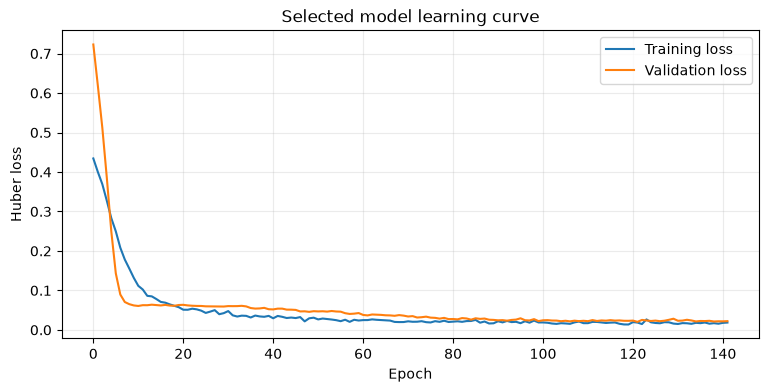

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(best_history['train_loss'], label='Training loss')
ax.plot(best_history['validation_loss'], label='Validation loss')
ax.set(title='Selected model learning curve', xlabel='Epoch', ylabel='Huber loss')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 6. Final untouched-test evaluation

The test set is evaluated once, after selecting the lookback and number of units from validation results.

In [15]:
X_test, y_test_scaled, test_dates, selected_test_rows = best_parts['test']
lstm_scaled = predict_scaled(best_model, X_test)
lstm_prediction = target_scaler.inverse_transform(lstm_scaled.reshape(-1, 1)).ravel()
lstm_actual = target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

assert np.array_equal(selected_test_rows, test_rows)
all_results = baseline_results.copy()
all_results.loc['LSTM'] = regression_metrics(lstm_actual, lstm_prediction)
display(all_results)

predictions = pd.DataFrame({
    'date': test_dates,
    'actual': lstm_actual,
    'LSTM': lstm_prediction,
    'persistence': persistence,
    'seasonal_naive': seasonal_naive,
})
display(predictions.head())

,MAE,RMSE,MAPE_safe,R2,Bias_actual_minus_predicted
Persistence,1.459278,2.157082,22.507127,0.788842,0.069023
Seasonal naive,6.364228,7.507906,89.529854,-1.558072,2.736075
LSTM,4.332987,5.583917,41.395683,-0.414989,4.109995


,date,actual,LSTM,persistence,seasonal_naive
0,2021-01-01,3.375121,3.328406,3.592233,3.286853
1,2021-02-01,3.646833,3.218582,3.375121,3.578529
2,2021-03-01,7.324234,3.219630,3.646833,3.366337
3,2021-04-01,11.907553,3.837444,7.324234,3.155819
4,2021-05-01,12.555894,4.968781,11.907553,3.137255


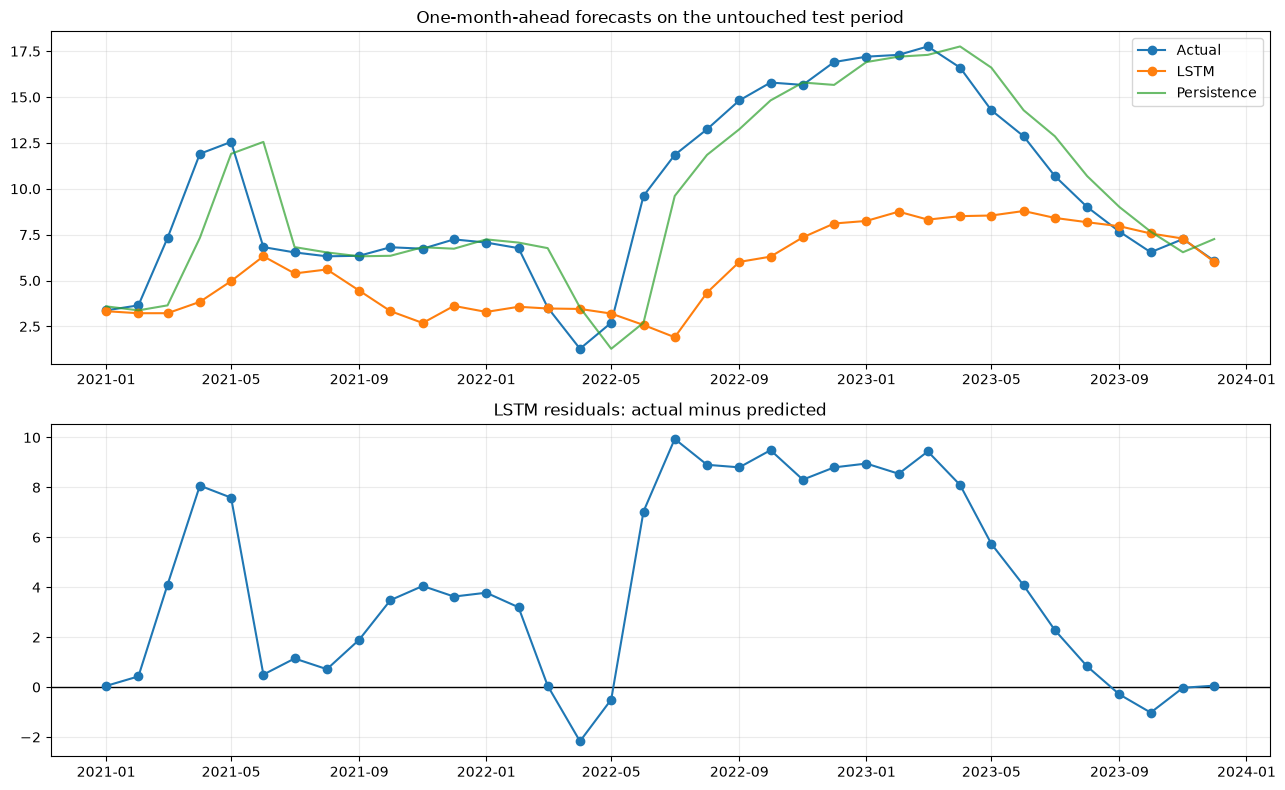

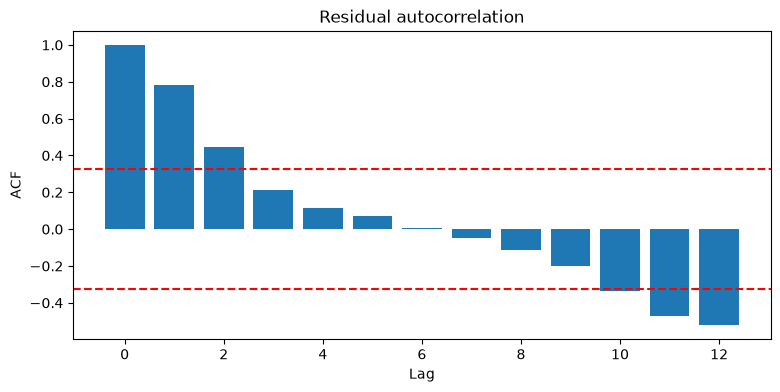

Mean residual (forecast bias): 4.109995
Largest absolute errors:


,date,actual,LSTM,persistence,seasonal_naive,residual,absolute_error
18,2022-07-01,11.848774,1.909253,9.611358,6.532611,9.939521,9.939521
21,2022-10-01,15.793030,6.303012,14.817501,6.815183,9.490018,9.490018
26,2023-03-01,17.759535,8.320698,17.300828,3.527643,9.438837,9.438837
24,2023-01-01,17.202728,8.248863,16.909133,7.069310,8.953865,8.953865
19,2022-08-01,13.246103,4.341511,11.848774,6.320939,8.904593,8.904593


In [16]:
residuals = lstm_actual - lstm_prediction

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
axes[0].plot(test_dates, lstm_actual, marker='o', label='Actual')
axes[0].plot(test_dates, lstm_prediction, marker='o', label='LSTM')
axes[0].plot(test_dates, persistence, alpha=0.7, label='Persistence')
axes[0].set_title('One-month-ahead forecasts on the untouched test period')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].axhline(0, color='black', linewidth=1)
axes[1].plot(test_dates, residuals, marker='o')
axes[1].set_title('LSTM residuals: actual minus predicted')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

def residual_acf(values, max_lag=12):
    values = np.asarray(values) - np.mean(values)
    denominator = np.dot(values, values)
    return np.array([1.0] + [np.dot(values[:-lag], values[lag:]) / denominator
                              for lag in range(1, max_lag + 1)])

acf_values = residual_acf(residuals, min(12, len(residuals) - 1))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(acf_values)), acf_values)
bound = 1.96 / np.sqrt(len(residuals))
ax.axhline(bound, color='red', linestyle='--')
ax.axhline(-bound, color='red', linestyle='--')
ax.set(title='Residual autocorrelation', xlabel='Lag', ylabel='ACF')
plt.show()

print('Mean residual (forecast bias):', residuals.mean())
print('Largest absolute errors:')
display(predictions.assign(residual=residuals, absolute_error=np.abs(residuals))
        .nlargest(5, 'absolute_error'))

## 7. Interpretation checklist

Before drawing a conclusion:

1. Confirm Model 1 uses the same January 2021–December 2023 test targets, or update the split above.
2. Add Model 1's test metrics to the comparison table.
3. Check whether the LSTM beats persistence in both MAE and RMSE.
4. Inspect residual bias and autocorrelation rather than treating residual normality as the main criterion.
5. Discuss the small sample (276 months), structural breaks, predictor publication timing, and overfitting risk.
6. Do not claim that contemporaneous economic inputs are available for forecasting unless their release dates support that assumption.